In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Reproduzierbarkeit für alle Frameworks
torch.manual_seed(1)
np.random.seed(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)
n = 360
t = np.arange(n)
trend = 0.03 * t
seasonal_daily = 1.5 * np.sin(2 * np.pi * t / 24)
seasonal_weekly = 0.8 * np.cos(2 * np.pi * t / (24 * 7))
noise = np.random.normal(0, 0.35, size=n)
series = 15 + trend + seasonal_daily + seasonal_weekly + noise
df = pd.DataFrame({'time': t, 'value': series})
df.head()

def make_supervised(series: np.ndarray, lookback: int = 24, horizon: int = 1):
    X, y = [], []
    for end in range(lookback, len(series) - horizon + 1):
        start = end - lookback
        X.append(series[start:end]) # Fenster 
        y.append(series[end + horizon - 1]) # Zielhorizont 
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

lookback = 24 * 7
X, y = make_supervised(df['value'].to_numpy(), lookback=lookback, horizon=1)
X.shape, y.shape

Device: mps


((192, 168), (192,))

In [34]:
n_samples = len(X)

# Training -> Test 
# Training -> Validation -> Test (garantiert Holdout/OOS)


train_end = int(n_samples*0.7) 
val_end = int(n_samples*0.85) 
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end] 
X_test, y_test = X[val_end:], y[val_end:]

# Vorarbeitung für MLP, NN = Normalisierung (Datensatz muss Mittelwert = 0, Standardabweichung = 1 haben)
x_mean, x_std = X_train.mean(), X_train.std() # Mittelwert & Standardabweichung 
y_mean, y_std = y_train.mean(), y_train.std() # bei Regression auch bei y notwendig 

X_train_s = (X_train - x_mean)/x_std 
X_val_s = (X_val-x_mean) / x_std
X_test_s =(X_test-x_mean) / x_std

y_train_s = (y_train-y_mean)/y_std
y_val_s = (y_val-y_mean)/y_std

In [35]:
train_ds = TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train_s).unsqueeze(1))
val_ds = TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val_s).unsqueeze(1))
test_tensor = torch.Tensor(X_test_s)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True) # shuffle erlaubt, weil richtig gesplittet 
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

xb,yb = next(iter(train_loader))

xb.shape

torch.Size([32, 168])

In [42]:

class MyRNN(nn.Module):
    def __init__(self, hidden_size): # hidden_size ... Größe von h 
        super().__init__()
        self.hidden_size = hidden_size

        self.W_xh = nn.Linear(1, hidden_size) # weil univariat (bias = True )
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False  )
        self.W_hy = nn.Linear(hidden_size, 1) 
    
    def forward(self,x): # batchweise Verarbeitung
        batch_size, seq_len, _ = x.shape  
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        for t in range(seq_len):
            x_t = x[:,t,:] # [batch_size, 1], 
            h = torch.tanh(self.W_xh(x_t) + self.W_hh(h)) 
        y = self.W_hy(h) # Vorhersage 
        return y


model = MyRNN(hidden_size=32).to(device=device)
num_params = sum(p.numel() for p in model.parameters()) # Anzahl der Parameter 
num_params

1121

In [43]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3) # Adam ist das modernere Optimierungsverfahren 
# 1e-3 ist die erste Wahl für Adam 
loss_fn = nn.MSELoss() 

# Early Stopping Strategie (genau dafür braucht man val_ds )

best_val = float('inf') # der beste Run/die beste Epoche 
best_state = None # Gewichte/Biases speichern 
patience = 7 # 3,5,7,9, ... 
wait = 0 # Zähler 

epochs = 150

for epoch in range(epochs):
    model.train() # Model in das Trainingsmodus versetzen 
    train_losses = [] # Werte der Kostenfunktion für Batches 
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device) # Tensoren nach device bringen
        xb = xb.unsqueeze(-1) # 2D -> 3D 
        optimizer.zero_grad() 
        y_pred = model(xb)
        loss = loss_fn(yb, y_pred)
        
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item()) # .item() = tatsächliche Zahl zurückgeben
    
    model.eval() # Evaluierungsmodus 
    val_losses = []
    with torch.no_grad(): # Gradient wird nicht benötigt, weil wir evaluieren  
        for xb, yb in val_loader:
            xb, yb =xb.to(device), yb.to(device)
            xb = xb.unsqueeze(-1)
            y_pred = model(xb)
            loss = loss_fn(yb, y_pred)
            val_losses.append(loss.item())
    
    mean_loss_train = float(np.mean(train_losses)) 
    mean_loss_val = float(np.mean(val_losses))
    print(f"Epoch [{epoch+1}/{epochs}]: loss_train: {mean_loss_train}, loss_val: {mean_loss_val}")

    if mean_loss_val < best_val - 1e-3:
        best_val = mean_loss_val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()} # Gewichte speichern
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early Stopping")
            break

model.load_state_dict(best_state) # besten Gewichte laden 

Epoch [1/150]: loss_train: 0.737428605556488, loss_val: 2.8862645626068115
Epoch [2/150]: loss_train: 0.6638876378536225, loss_val: 2.466179847717285
Epoch [3/150]: loss_train: 0.5149451792240143, loss_val: 2.0552761554718018
Epoch [4/150]: loss_train: 0.38420061469078065, loss_val: 1.7278282642364502
Epoch [5/150]: loss_train: 0.32862369418144227, loss_val: 1.5532922744750977
Epoch [6/150]: loss_train: 0.26780076026916505, loss_val: 1.3757455348968506
Epoch [7/150]: loss_train: 0.2519837409257889, loss_val: 1.204991340637207
Epoch [8/150]: loss_train: 0.29034032821655276, loss_val: 1.080829381942749
Epoch [9/150]: loss_train: 0.22956398725509644, loss_val: 0.9724001288414001
Epoch [10/150]: loss_train: 0.22229592502117157, loss_val: 0.8615053296089172
Epoch [11/150]: loss_train: 0.20284256041049958, loss_val: 0.7692726254463196
Epoch [12/150]: loss_train: 0.1992863655090332, loss_val: 0.7223747968673706
Epoch [13/150]: loss_train: 0.16721134185791015, loss_val: 0.7239564061164856
Epoc

<All keys matched successfully>

In [44]:
model.eval()
with torch.no_grad():
    mlp_pred_s = model(test_tensor.to(device).unsqueeze(-1)).squeeze(1).cpu().numpy()
mlp_pred = mlp_pred_s * y_std + y_mean
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
pd.DataFrame([
    
    {'model': 'pytorch_rnn', 'mae': mlp_mae, 'rmse': mlp_rmse},
]).round(4)

,model,mae,rmse
0,pytorch_rnn,0.9851,1.2411


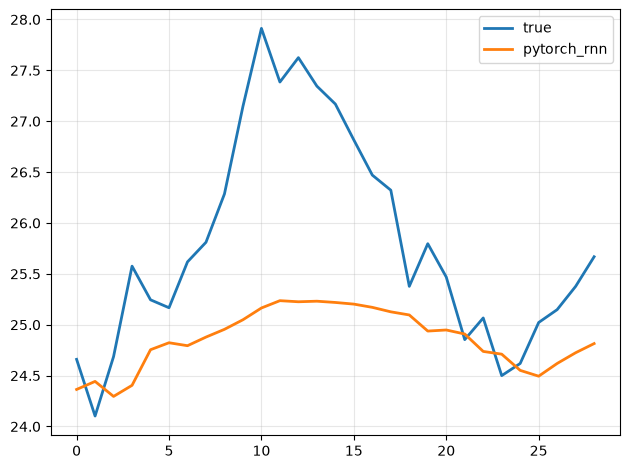

In [45]:
plt.plot(y_test, label='true', linewidth=2)
plt.plot(mlp_pred, label='pytorch_rnn', linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()